## Import Package

In [ ]:
#%matplotlib ipympl
import numpy as np
import deepxde as dde
import torch
from mpl_toolkits.mplot3d import Axes3D
dde.backend.set_default_backend('pytorch')
import matplotlib.pyplot as plt

Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


## Plotting Function

In [ ]:
def plot_loss_history(loss_history, savepath=None, figsize=(8, 6)):
    """Plot the training and testing loss history.

    Note:
        You need to call ``plt.show()`` to show the figure.

    Args:
        loss_history: ``LossHistory`` instance. The first variable returned from
            ``Model.train()``.
    """
    loss_train = np.sum(loss_history.loss_train, axis=1)
    loss_test = np.sum(loss_history.loss_test, axis=1)

    plt.figure(figsize=figsize)
    plt.semilogy(loss_history.steps, loss_train, label="Train loss")
    plt.semilogy(loss_history.steps, loss_test, label="Test loss")
    for i in range(len(loss_history.metrics_test[0])):
        plt.semilogy(
            loss_history.steps,
            np.array(loss_history.metrics_test)[:, i],
            label="Test metric",
        )
    plt.xlabel("Steps")
    plt.ylabel("loss")
    plt.legend()

    if savepath:
        plt.savefig(savepath)
    plt.show()
    plt.close()


def _pack_data(train_state):
    def merge_values(values):
        if values is None:
            return None
        return np.hstack(values) if isinstance(values, (list, tuple)) else values

    y_train = merge_values(train_state.y_train)
    y_test = merge_values(train_state.y_test)
    best_y = merge_values(train_state.best_y)
    best_ystd = merge_values(train_state.best_ystd)
    return y_train, y_test, best_y, best_ystd

def plot_best_state(train_state, savepath=None, figsize=(4, 3)):
    """Plot the best result of the smallest training loss.

    This function only works for 1D and 2D problems. For other problems and to better
    customize the figure, use ``save_best_state()``.

    Note:
        You need to call ``plt.show()`` to show the figure.

    Args:
        train_state: ``TrainState`` instance. The second variable returned from
            ``Model.train()``.
    """
    if isinstance(train_state.X_train, (list, tuple)):
        print(
            "Error: The network has multiple inputs, and plotting such result han't been implemented."
        )
        return

    y_train, y_test, best_y, best_ystd = _pack_data(train_state)
    y_dim = best_y.shape[1]

    # Regression plot
    # 1D
    if train_state.X_test.shape[1] == 1:
        idx = np.argsort(train_state.X_test[:, 0])
        X = train_state.X_test[idx, 0]
        plt.figure(figsize=figsize)
        for i in range(y_dim):
            if y_train is not None:
                plt.plot(train_state.X_train[:, 0], y_train[:, i], "ok", label="Train")
            if y_test is not None:
                plt.plot(X, y_test[idx, i], "-k", label="True")
            plt.plot(X, best_y[idx, i], "--r", label="Prediction")
            if best_ystd is not None:
                plt.plot(
                    X, best_y[idx, i] + 2 * best_ystd[idx, i], "-b", label="95% CI"
                )
                plt.plot(X, best_y[idx, i] - 2 * best_ystd[idx, i], "-b")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
    # 2D
    elif train_state.X_test.shape[1] == 2:
        for i in range(y_dim):
            plt.figure(figsize=tuple([i*2 for i in figsize]))
            ax = plt.axes(projection=Axes3D.name)
            ax.plot3D(
                train_state.X_test[:, 0],
                train_state.X_test[:, 1],
                best_y[:, i],
                ".",
            )
            ax.set_xlabel("$x_1$")
            ax.set_ylabel("$x_2$")
            ax.set_zlabel("$y_{}$".format(i + 1))

    if savepath:
        plt.savefig(savepath)
    plt.show()
    plt.close()

## Setting PDE

In [ ]:
c=1
def pde(x,y):
    d2y_dx2 = dde.grad.hessian(y,x,i=0,j=0)
    d2y_dt2 = dde.grad.hessian(y,x,i=1,j=1)
    return d2y_dx2 - c**2 * d2y_dt2

## Setting Exact Solution

In [ ]:
A=2
def func(x):
    x, t = np.split(x,2,axis=1)
    return np.sin(np.pi*x) * np.cos(c*np.pi*t) + np.sin(A*np.pi*x) * np.cos(A*c*np.pi*t)

## Defining Domain

In [ ]:
geom = dde.geometry.Interval(0,1)
timedomain = dde.geometry.TimeDomain(0,1)
geomtime = dde.geometry.GeometryXTime(geom,timedomain)

## Setting Boundary Condition and Initial Condition

In [ ]:
bc = dde.icbc.DirichletBC(geomtime, func, lambda _,on_boundary: on_boundary)
ic_1 = dde.icbc.IC(geomtime, func, lambda _, on_boundary: on_boundary)
ic_2 = dde.icbc.OperatorBC(geomtime, lambda x, y, _ : dde.grad.jacobian(y, x, i=0, j=1), lambda x,_ : dde.utils.isclose(x[1],0))

## Construct PDE Data

In [ ]:
data = dde.data.TimePDE(geomtime, pde, [bc, ic_1, ic_2], num_domain=1000, num_boundary=1000, num_initial=500, solution=func, num_test=1000)

## Neural Network Architecture

In [ ]:
hidden_layer_counts = [2, 3, 4]
neuron_counts = [100, 300, 500]

## Construct & Training Model (Intermediate Level)

Training model with 2 hidden layers and 100 neurons per layer...

Compiling model...
'compile' took 0.000154 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [1.33e-04, 1.06e-02, 1.00e+00, 3.33e-02]    [8.10e-05, 1.06e-02, 1.00e+00, 3.33e-02]    [1.02e+00]    
1000      [7.25e-04, 3.55e-02, 3.33e-02, 1.03e-03]    [1.62e-03, 3.55e-02, 3.33e-02, 1.03e-03]    [3.08e-01]    
2000      [2.38e-03, 3.16e-02, 8.58e-03, 2.08e-03]    [3.62e-03, 3.16e-02, 8.58e-03, 2.08e-03]    [2.26e-01]    
3000      [6.89e-04, 2.03e-02, 3.30e-03, 1.65e-04]    [1.13e-03, 2.03e-02, 3.30e-03, 1.65e-04]    [1.65e-01]    
4000      [8.73e-04, 3.04e-03, 4.40e-04, 2.34e-04]    [1.17e-03, 3.04e-03, 4.40e-04, 2.34e-04]    [5.80e-02]    
5000      [2.88e-04, 6.06e-04, 1.44e-04, 5.85e-05]    [6.70e-04, 6.06e-04, 1.44e-04, 5.85e-05]    [2.68e-02]    
6000      [1.99e-03, 2.39e-04, 1.16e-04, 1.43e-04]    [2.23e-03, 2.39e-04, 1.1

<Figure size 640x480 with 0 Axes>

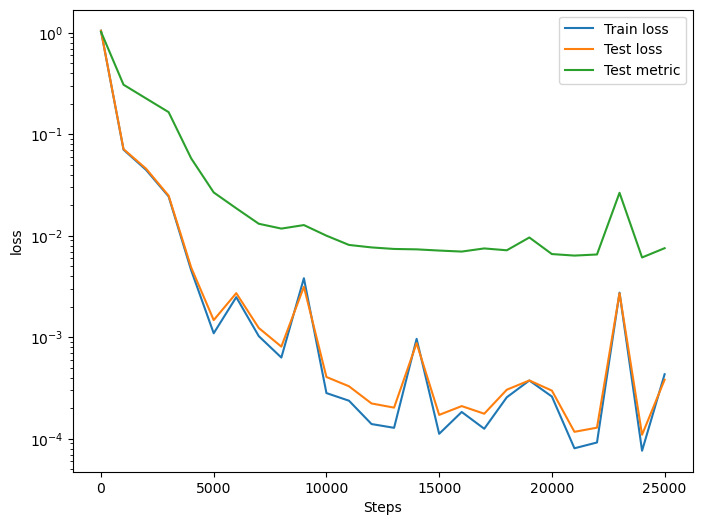

<Figure size 640x480 with 0 Axes>

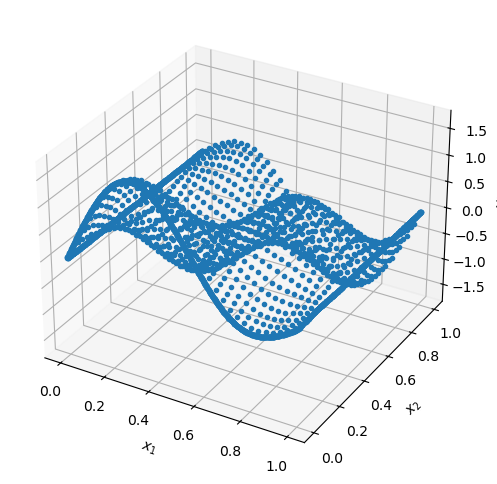

Training model with 2 hidden layers and 300 neurons per layer...

Compiling model...
'compile' took 0.000090 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [5.99e-06, 7.86e-04, 9.97e-01, 3.60e-03]    [6.63e-06, 7.86e-04, 9.97e-01, 3.60e-03]    [9.93e-01]    
1000      [2.87e-04, 3.41e-02, 5.03e-02, 4.07e-04]    [4.29e-04, 3.41e-02, 5.03e-02, 4.07e-04]    [3.39e-01]    
2000      [5.58e-04, 3.38e-02, 1.30e-02, 1.45e-03]    [9.39e-04, 3.38e-02, 1.30e-02, 1.45e-03]    [2.50e-01]    
3000      [8.09e-03, 2.40e-02, 4.65e-03, 3.55e-03]    [8.84e-03, 2.40e-02, 4.65e-03, 3.55e-03]    [1.85e-01]    
4000      [5.29e-04, 5.31e-03, 9.36e-04, 1.49e-04]    [1.14e-03, 5.31e-03, 9.36e-04, 1.49e-04]    [7.94e-02]    
5000      [4.00e-04, 1.94e-03, 3.83e-04, 8.53e-05]    [7.59e-04, 1.94e-03, 3.83e-04, 8.53e-05]    [4.72e-02]    
6000      [3.59e-04, 9.67e-04, 2.50e-04, 4.61e-05]    [6.48e-04, 9.67e-04, 2.5

<Figure size 640x480 with 0 Axes>

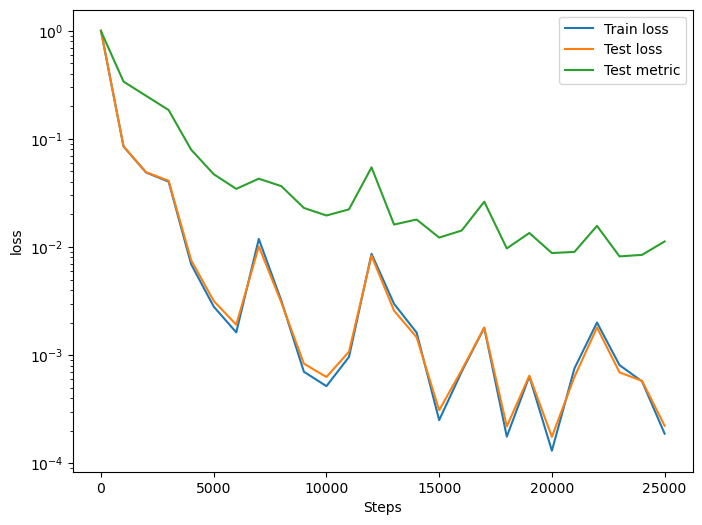

<Figure size 640x480 with 0 Axes>

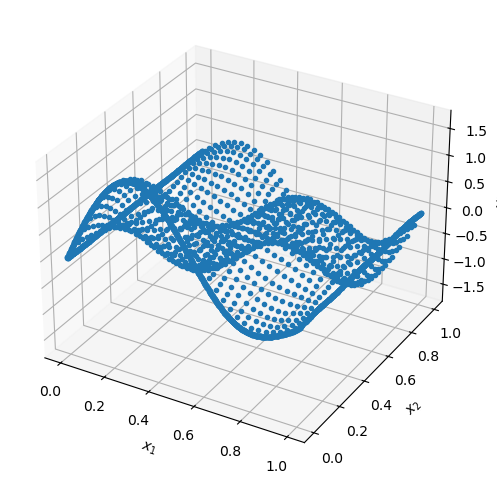

Training model with 2 hidden layers and 500 neurons per layer...

Compiling model...
'compile' took 0.000101 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [1.15e-05, 2.42e-03, 1.00e+00, 7.37e-03]    [1.47e-05, 2.42e-03, 1.00e+00, 7.37e-03]    [1.01e+00]    
1000      [3.19e-04, 3.58e-02, 3.86e-02, 6.35e-04]    [4.87e-04, 3.58e-02, 3.86e-02, 6.35e-04]    [3.23e-01]    
2000      [1.02e-03, 3.46e-02, 1.21e-02, 5.74e-04]    [1.04e-03, 3.46e-02, 1.21e-02, 5.74e-04]    [2.51e-01]    
3000      [1.23e-02, 3.15e-02, 6.76e-03, 4.28e-03]    [8.43e-03, 3.15e-02, 6.76e-03, 4.28e-03]    [2.19e-01]    
4000      [6.53e-04, 8.81e-03, 1.99e-03, 5.48e-04]    [8.33e-04, 8.81e-03, 1.99e-03, 5.48e-04]    [1.11e-01]    
5000      [3.66e-04, 2.46e-03, 4.57e-04, 8.95e-05]    [8.05e-04, 2.46e-03, 4.57e-04, 8.95e-05]    [5.38e-02]    
6000      [1.72e-04, 1.28e-03, 2.45e-04, 7.79e-05]    [3.83e-04, 1.28e-03, 2.4

<Figure size 640x480 with 0 Axes>

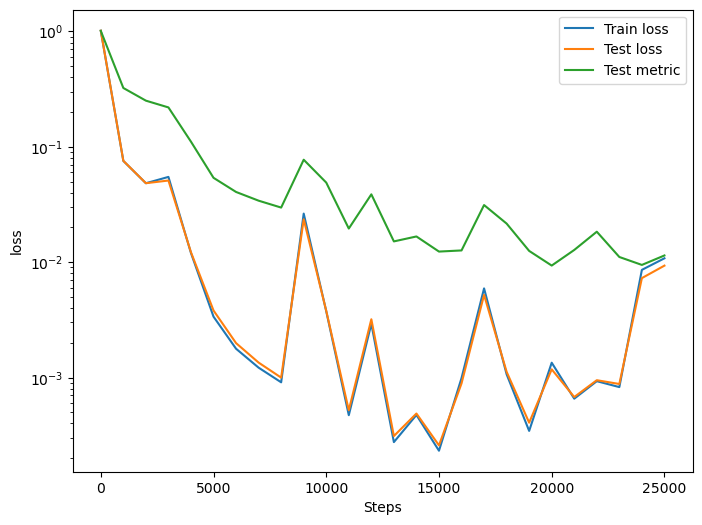

<Figure size 640x480 with 0 Axes>

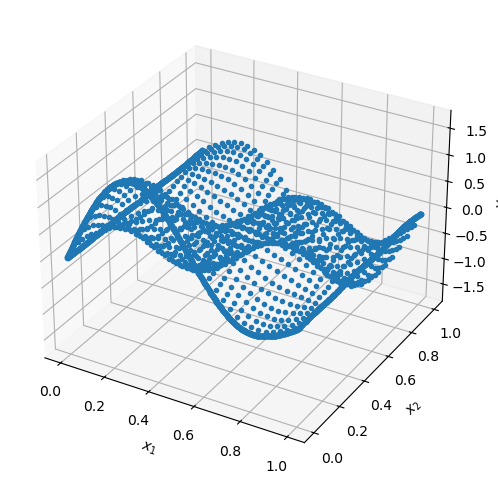

Training model with 3 hidden layers and 100 neurons per layer...

Compiling model...
'compile' took 0.000129 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [6.60e-05, 8.43e-04, 9.91e-01, 2.14e-04]    [8.61e-05, 8.43e-04, 9.91e-01, 2.14e-04]    [9.97e-01]    
1000      [9.10e-04, 3.46e-02, 4.47e-02, 3.48e-04]    [1.76e-03, 3.46e-02, 4.47e-02, 3.48e-04]    [3.30e-01]    
2000      [1.71e-02, 3.49e-02, 1.95e-02, 2.34e-03]    [1.62e-02, 3.49e-02, 1.95e-02, 2.34e-03]    [2.71e-01]    
3000      [1.57e-03, 3.02e-02, 7.98e-03, 1.13e-03]    [2.59e-03, 3.02e-02, 7.98e-03, 1.13e-03]    [2.19e-01]    
4000      [1.06e-03, 8.51e-03, 1.33e-03, 1.76e-04]    [2.32e-03, 8.51e-03, 1.33e-03, 1.76e-04]    [1.02e-01]    
5000      [3.92e-04, 1.77e-03, 2.03e-04, 4.66e-05]    [8.28e-04, 1.77e-03, 2.03e-04, 4.66e-05]    [4.39e-02]    
6000      [2.54e-04, 7.56e-04, 1.32e-04, 7.48e-05]    [5.34e-04, 7.56e-04, 1.3

<Figure size 640x480 with 0 Axes>

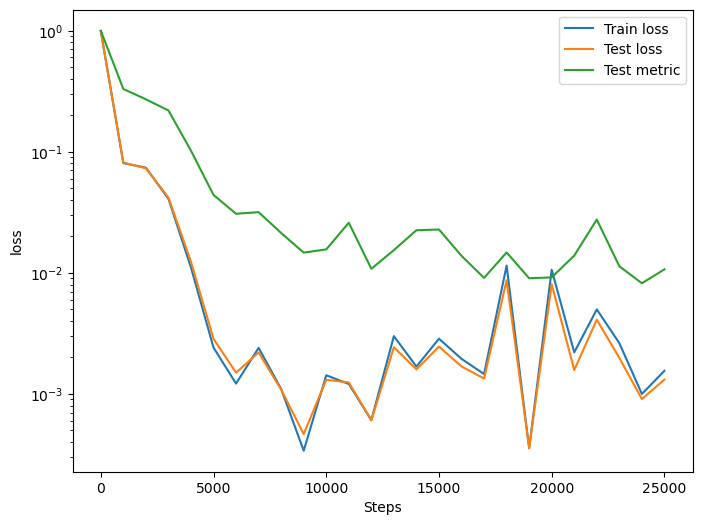

<Figure size 640x480 with 0 Axes>

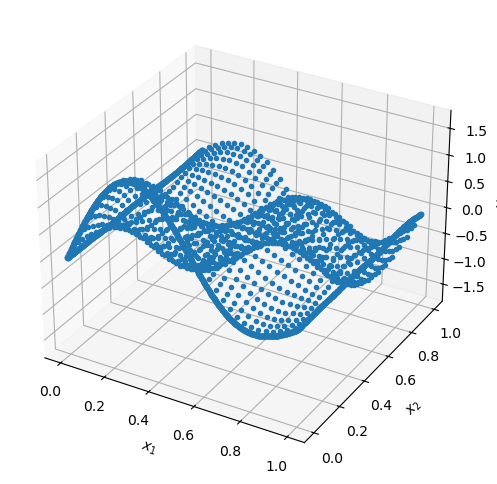

Training model with 3 hidden layers and 300 neurons per layer...

Compiling model...
'compile' took 0.000117 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [3.67e-05, 1.68e-03, 1.01e+00, 4.54e-03]    [3.43e-05, 1.68e-03, 1.01e+00, 4.54e-03]    [9.96e-01]    
1000      [8.59e-04, 3.31e-02, 2.23e-02, 7.15e-04]    [1.65e-03, 3.31e-02, 2.23e-02, 7.15e-04]    [2.81e-01]    
2000      [1.21e-03, 3.33e-02, 1.27e-02, 6.00e-04]    [2.09e-03, 3.33e-02, 1.27e-02, 6.00e-04]    [2.51e-01]    
3000      [3.09e-03, 1.67e-02, 7.17e-03, 9.79e-04]    [3.76e-03, 1.67e-02, 7.17e-03, 9.79e-04]    [1.78e-01]    
4000      [1.28e-03, 7.22e-03, 2.20e-03, 2.49e-04]    [1.86e-03, 7.22e-03, 2.20e-03, 2.49e-04]    [1.08e-01]    
5000      [2.88e-04, 4.62e-03, 1.35e-03, 8.02e-05]    [5.14e-04, 4.62e-03, 1.35e-03, 8.02e-05]    [8.45e-02]    
6000      [1.19e-01, 4.50e-03, 8.14e-04, 6.41e-03]    [1.11e-01, 4.50e-03, 8.1

<Figure size 640x480 with 0 Axes>

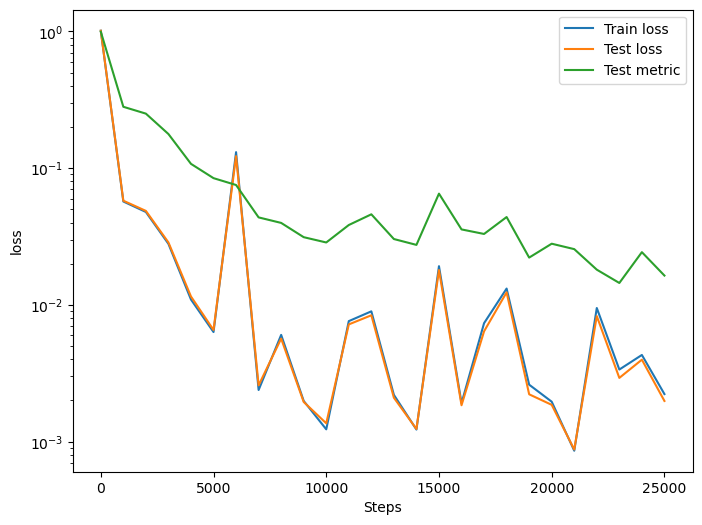

<Figure size 640x480 with 0 Axes>

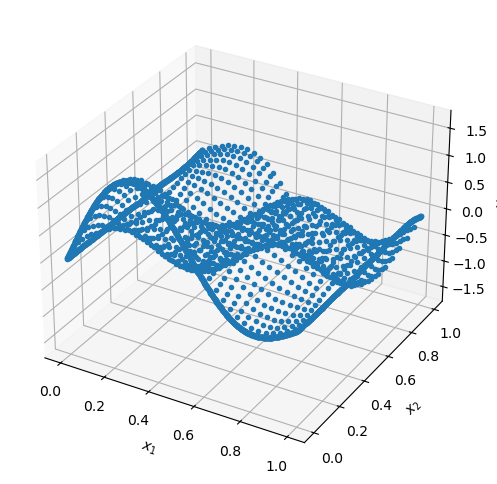

Training model with 3 hidden layers and 500 neurons per layer...

Compiling model...
'compile' took 0.000113 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [9.45e-06, 1.08e-02, 1.02e+00, 1.80e-02]    [6.36e-06, 1.08e-02, 1.02e+00, 1.80e-02]    [1.00e+00]    
1000      [2.59e-01, 4.08e-02, 2.47e-02, 3.17e-02]    [2.88e-01, 4.08e-02, 2.47e-02, 3.17e-02]    [3.14e-01]    
2000      [1.30e-03, 2.20e-02, 8.45e-03, 1.27e-03]    [2.41e-03, 2.20e-02, 8.45e-03, 1.27e-03]    [2.05e-01]    
3000      [3.45e-03, 1.01e-02, 3.19e-03, 1.08e-04]    [4.28e-03, 1.01e-02, 3.19e-03, 1.08e-04]    [1.29e-01]    
4000      [8.90e-03, 7.27e-03, 7.61e-03, 3.44e-03]    [8.29e-03, 7.27e-03, 7.61e-03, 3.44e-03]    [1.46e-01]    
5000      [2.44e-03, 4.77e-03, 1.33e-03, 1.60e-04]    [2.18e-03, 4.77e-03, 1.33e-03, 1.60e-04]    [8.66e-02]    
6000      [3.39e-02, 4.79e-03, 2.12e-03, 1.41e-03]    [3.06e-02, 4.79e-03, 2.1

<Figure size 640x480 with 0 Axes>

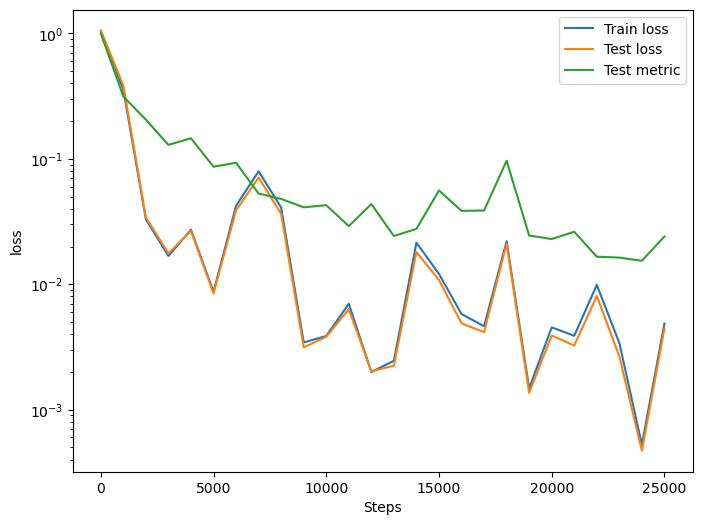

<Figure size 640x480 with 0 Axes>

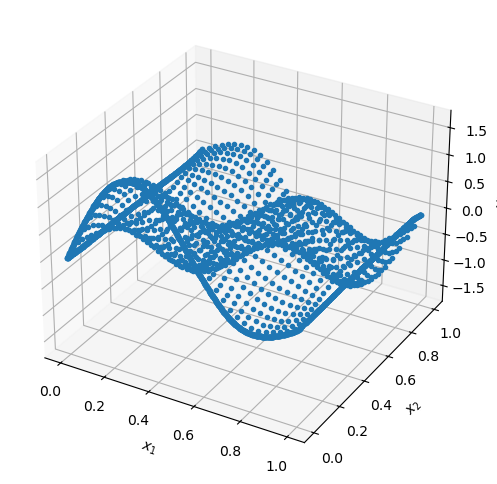

Training model with 4 hidden layers and 100 neurons per layer...

Compiling model...
'compile' took 0.000161 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [3.61e-03, 3.80e-02, 1.13e+00, 5.70e-05]    [3.55e-03, 3.80e-02, 1.13e+00, 5.70e-05]    [1.06e+00]    
1000      [1.34e-03, 3.41e-02, 2.83e-02, 2.67e-03]    [2.34e-03, 3.41e-02, 2.83e-02, 2.67e-03]    [2.94e-01]    
2000      [9.06e-04, 3.42e-02, 1.57e-02, 2.49e-03]    [1.74e-03, 3.42e-02, 1.57e-02, 2.49e-03]    [2.59e-01]    
3000      [1.89e-03, 3.24e-02, 1.10e-02, 1.36e-03]    [3.43e-03, 3.24e-02, 1.10e-02, 1.36e-03]    [2.37e-01]    
4000      [1.72e-02, 1.76e-02, 3.61e-03, 1.24e-03]    [1.60e-02, 1.76e-02, 3.61e-03, 1.24e-03]    [1.58e-01]    
5000      [5.30e-03, 4.83e-03, 8.42e-04, 1.93e-04]    [6.19e-03, 4.83e-03, 8.42e-04, 1.93e-04]    [7.57e-02]    
6000      [4.66e-04, 1.69e-03, 3.85e-04, 6.65e-05]    [9.60e-04, 1.69e-03, 3.8

<Figure size 640x480 with 0 Axes>

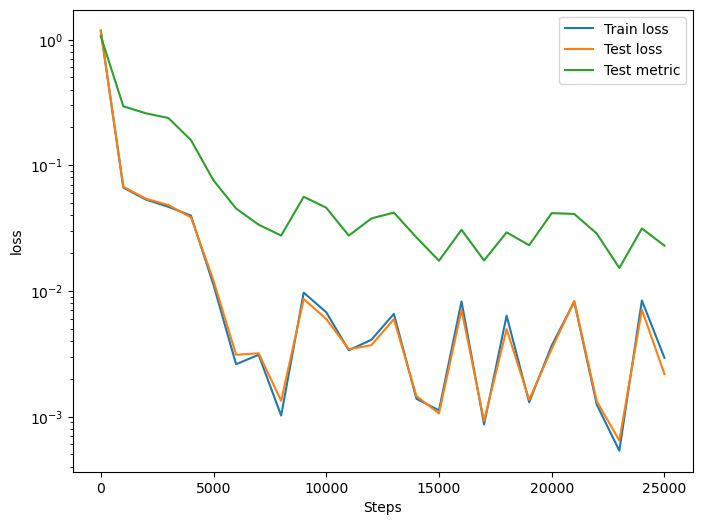

<Figure size 640x480 with 0 Axes>

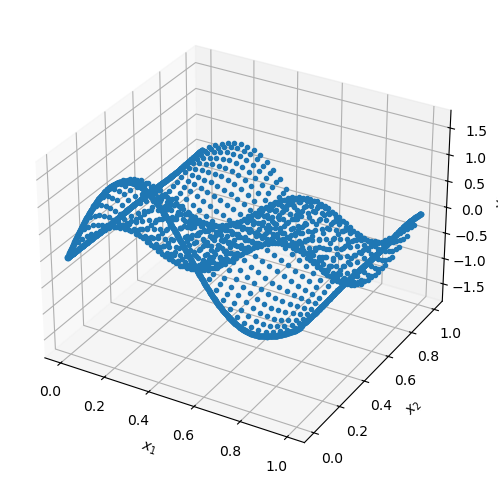

Training model with 4 hidden layers and 300 neurons per layer...

Compiling model...
'compile' took 0.000168 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [2.94e-04, 1.41e-02, 1.09e+00, 9.31e-03]    [2.93e-04, 1.41e-02, 1.09e+00, 9.31e-03]    [1.04e+00]    
1000      [8.58e-04, 3.94e-02, 2.50e-02, 1.55e-03]    [1.57e-03, 3.94e-02, 2.50e-02, 1.55e-03]    [3.07e-01]    
2000      [6.42e-04, 2.47e-02, 7.90e-03, 4.64e-04]    [1.45e-03, 2.47e-02, 7.90e-03, 4.64e-04]    [2.10e-01]    
3000      [7.30e-04, 1.49e-02, 5.50e-03, 1.02e-03]    [1.24e-03, 1.49e-02, 5.50e-03, 1.02e-03]    [1.63e-01]    
4000      [5.50e-03, 4.86e-03, 3.31e-03, 2.82e-04]    [4.24e-03, 4.86e-03, 3.31e-03, 2.82e-04]    [9.49e-02]    
5000      [1.24e-01, 3.37e-03, 1.38e-03, 2.67e-03]    [1.06e-01, 3.37e-03, 1.38e-03, 2.67e-03]    [7.32e-02]    
6000      [1.80e-01, 5.68e-03, 3.03e-03, 1.18e-02]    [1.43e-01, 5.68e-03, 3.0

<Figure size 640x480 with 0 Axes>

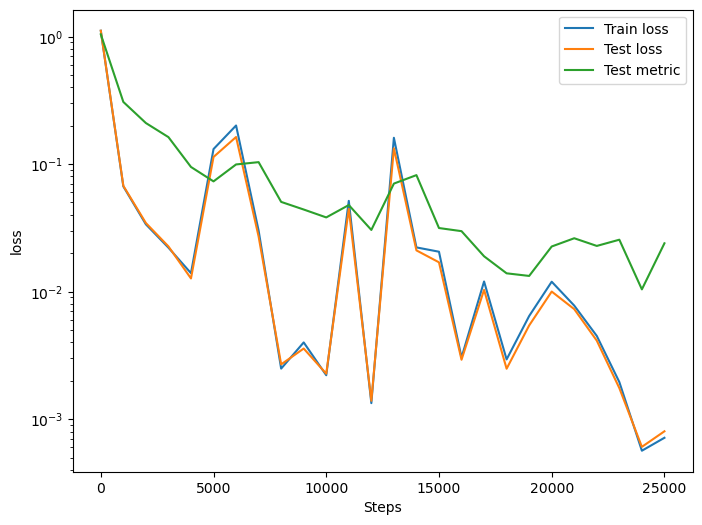

<Figure size 640x480 with 0 Axes>

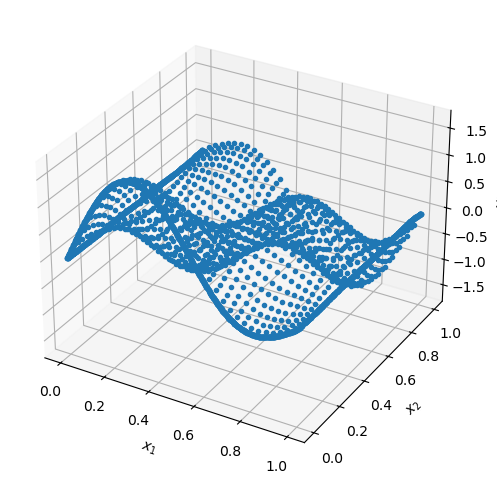

Training model with 4 hidden layers and 500 neurons per layer...

Compiling model...
'compile' took 0.000113 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [1.46e-04, 9.17e-03, 1.02e+00, 3.68e-02]    [1.87e-04, 9.17e-03, 1.02e+00, 3.68e-02]    [1.03e+00]    
1000      [1.77e-01, 9.79e-02, 1.94e-01, 5.55e-02]    [2.59e-01, 9.79e-02, 1.94e-01, 5.55e-02]    [6.47e-01]    
2000      [2.66e-03, 3.54e-02, 3.45e-02, 3.11e-03]    [1.62e-03, 3.54e-02, 3.45e-02, 3.11e-03]    [3.20e-01]    
3000      [4.74e-04, 3.59e-02, 1.67e-02, 4.69e-04]    [7.07e-04, 3.59e-02, 1.67e-02, 4.69e-04]    [2.69e-01]    
4000      [1.28e-03, 2.54e-02, 6.58e-03, 7.38e-04]    [1.95e-03, 2.54e-02, 6.58e-03, 7.38e-04]    [2.04e-01]    
5000      [6.85e-04, 2.92e-02, 1.10e-02, 5.53e-04]    [1.20e-03, 2.92e-02, 1.10e-02, 5.53e-04]    [2.30e-01]    
6000      [7.04e-04, 2.02e-02, 9.49e-03, 3.81e-04]    [1.32e-03, 2.02e-02, 9.4

<Figure size 640x480 with 0 Axes>

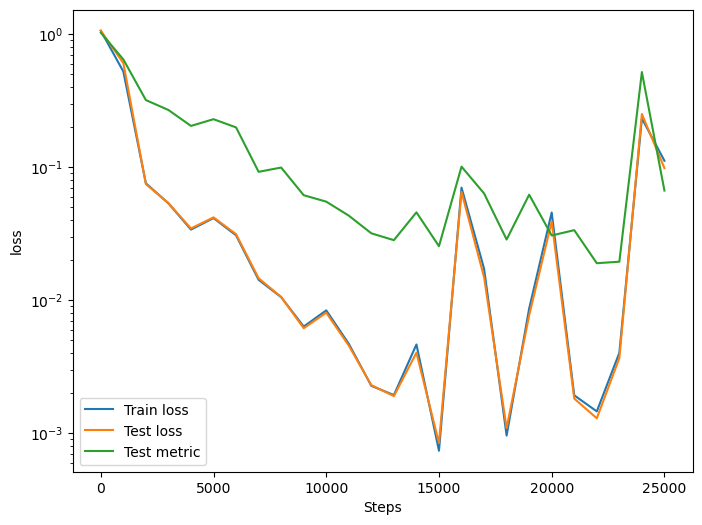

<Figure size 640x480 with 0 Axes>

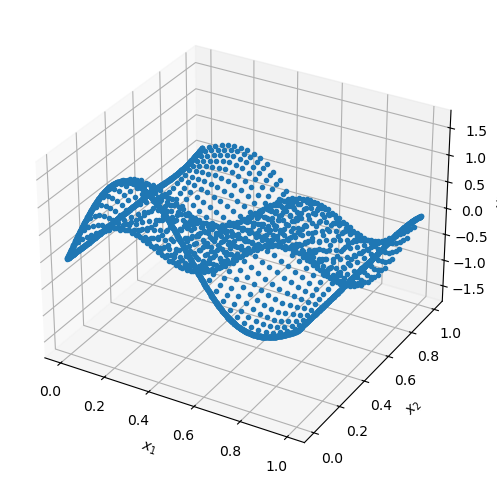

In [ ]:
for hidden_layers in hidden_layer_counts:
    for neurons in neuron_counts:
        print(f"Training model with {hidden_layers} hidden layers and {neurons} neurons per layer...\n")

        layer_size = [2] + [neurons] * hidden_layers + [1]
        activation = 'tanh'
        initializer = 'Glorot uniform'
        net = dde.nn.FNN(layer_size, activation, initializer)

        model = dde.Model(data, net)
        model.compile('adam', lr=0.001, metrics=["l2 relative error"])

        losshistory, train_state = model.train(iterations=25000)

        plt.figure()
        plot_loss_history(losshistory, savepath=f"loss_history_{hidden_layers}_{neurons}.png")
        plt.show()
        plt.close()

        plt.figure()
        plot_best_state(train_state, savepath=f"best_state_{hidden_layers}_{neurons}.png")
        plt.show()
        plt.close()

## Analytical Solution (Advanced Level)

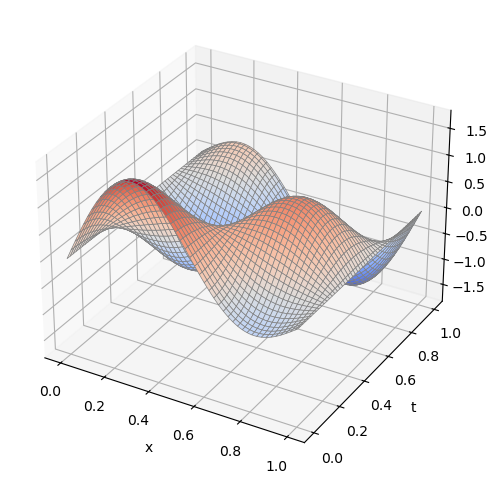

In [ ]:
x, t = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
Z = np.sin(np.pi*x) * np.cos(c*np.pi*t) + np.sin(A*np.pi*x) * np.cos(A*c*np.pi*t)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(x,t,Z, rstride=2, cstride=2, cmap=plt.get_cmap('coolwarm'), edgecolor='gray', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_zlabel('E')

plt.savefig('Advanced_Level.png')
plt.show()